# Lawgic Agent — Agentic RAG for CUAD Contract Analysis

This notebook implements the **Agentic Shift** — transitioning from a static RAG pipeline
to a self-correcting LangGraph agent.

**Key changes from `langchain_test.ipynb`:**
- **Removed** the Cross-Encoder Reranker (ms-marco caused regression on legal text)
- **Wider retrieval window**: `k=15` chunks instead of `k=4`
- **LLM-as-selector**: Llama-3.3-70B reasons over all retrieved chunks directly
- **Self-correction**: Agent re-queries when it detects missing context (e.g., "See Annex A")
- **Table-aware**: Strategy for handling tabular data in contracts via `pymupdf4llm`

**Architecture:**
```
START → [Retrieve (Hybrid k=15)] → [Analyze (LLM)] → END
                                        ↓ (needs more context)
                                   [Re-Retrieve] → [Analyze] → END
```

In [10]:
# Uncomment as needed:
# %pip install langchain langchain-community langchain-groq langchain-huggingface
# %pip install langchain-chroma sentence-transformers
# %pip install langchain-classic
%pip install langgraph
# %pip install rank_bm25
# %pip install pymupdf4llm

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Dict, Optional

from dotenv import load_dotenv
load_dotenv()

True

# 1. Setup

In [2]:
import torch
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

# LLM — Llama 3.3 70B for agentic reasoning (large context, strong legal comprehension)
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

# Embeddings — same as langchain_test.ipynb for vector store compatibility
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

# Device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [4]:
import glob
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Connect to existing CUAD vector store (36,730 documents, built in langchain_test.ipynb)
cuad_v1_vector_store = Chroma(
    collection_name="cuad_v1_collection",
    embedding_function=embeddings,
    persist_directory="../collections/cuad_v1_collection",
)
print(f"CUAD v1 vector store: {cuad_v1_vector_store._collection.count()} documents")

# Load CUAD JSON (ground truth)
CUAD_PATH = "../datasets/CUAD_v1/CUAD_v1.json"
with open(CUAD_PATH) as f:
    cuad_data = json.load(f)
print(f"CUAD dataset: {len(cuad_data['data'])} contracts")

# Build PDF path lookup (must catch both .PDF and .pdf extensions)
PDF_BASE_DIR = "../datasets/CUAD_v1/full_contract_pdf"

all_pdf_paths = glob.glob(os.path.join(PDF_BASE_DIR, "**", "*.PDF"), recursive=True)
all_pdf_paths += glob.glob(os.path.join(PDF_BASE_DIR, "**", "*.pdf"), recursive=True)
all_pdf_paths = list(set(all_pdf_paths))

pdf_path_lookup: Dict[str, str] = {}
for p in all_pdf_paths:
    title = Path(p).stem
    pdf_path_lookup[title] = p

print(f"Found {len(pdf_path_lookup)} PDF files")
matched = sum(1 for c in cuad_data['data'] if c['title'] in pdf_path_lookup)
print(f"Matched {matched}/{len(cuad_data['data'])} contracts to PDFs")

CUAD v1 vector store: 36730 documents
CUAD dataset: 510 contracts
Found 510 PDF files
Matched 506/510 contracts to PDFs


# 2. Benchmark Helper Functions

Carried over from `langchain_test.ipynb` — used for retrieval evaluation.

**Fast Metrics** (no API calls):
- **Hit Rate@K**: At least one relevant chunk in top-K?
- **MRR**: Mean Reciprocal Rank
- **Precision@K / Recall@K / NDCG@K**

In [5]:
def _normalize(text: str) -> str:
    """Collapse whitespace and lowercase for text comparison."""
    return re.sub(r'\s+', ' ', text.lower().strip())


def _text_in(needle: str, haystack: str, min_words: int = 6) -> bool:
    """Check if needle text appears in haystack (handles whitespace differences).

    For longer texts, also checks if a contiguous segment of min_words
    consecutive words from the needle appears in the haystack.
    """
    n, h = _normalize(needle), _normalize(haystack)
    if n in h:
        return True
    words = n.split()
    if len(words) >= min_words:
        for i in range(len(words) - min_words + 1):
            if ' '.join(words[i:i + min_words]) in h:
                return True
    return False


def _text_in_any(text: str, answer_texts: List[str]) -> bool:
    """Check if text contains any of the answer texts."""
    return any(_text_in(ans, text) for ans in answer_texts)


print("Defined text matching helpers.")

Defined text matching helpers.


In [6]:
def build_eval_dataset(
    cuad_path: str,
    contract_title: str,
    chunks: list,
    custom_samples: Optional[List[Dict]] = None,
) -> List[Dict]:
    """Build retrieval evaluation dataset from CUAD annotations + custom queries.

    Maps CUAD ground-truth answer spans to actual document chunks.
    """
    with open(cuad_path) as f:
        cuad = json.load(f)

    contract = next((d for d in cuad['data'] if d['title'] == contract_title), None)
    if not contract:
        raise ValueError(f"Contract '{contract_title}' not found in CUAD")

    dataset = []

    for qa in contract['paragraphs'][0]['qas']:
        if qa.get('is_impossible') or not qa.get('answers'):
            continue

        answer_texts = list({a['text'] for a in qa['answers']})
        category = qa['id'].rsplit('__', 1)[-1] if '__' in qa['id'] else 'unknown'

        relevant_idx = set()
        for ans in answer_texts:
            for i, chunk in enumerate(chunks):
                if _text_in(ans, chunk.page_content):
                    relevant_idx.add(i)

        if relevant_idx:
            dataset.append({
                'query': qa['question'],
                'answer_texts': answer_texts,
                'reference_contexts': [chunks[i].page_content for i in sorted(relevant_idx)],
                'reference_chunk_indices': sorted(relevant_idx),
                'category': category,
            })

    for cs in (custom_samples or []):
        idx = [i for i, c in enumerate(chunks) if _text_in(cs['answer_text'], c.page_content)]
        if idx:
            dataset.append({
                'query': cs['query'],
                'answer_texts': [cs['answer_text']],
                'reference_contexts': [chunks[i].page_content for i in idx],
                'reference_chunk_indices': idx,
                'category': cs.get('category', 'custom'),
            })
        else:
            print(f"Warning: No matching chunks for custom query: {cs['query'][:60]}...")

    return dataset


print("Defined build_eval_dataset().")

Defined build_eval_dataset().


In [7]:
def evaluate_retrieval(
    retriever,
    eval_dataset: List[Dict],
    k: int = 4,
    chunks: Optional[list] = None,
    llm=None,
    run_llm_metrics: bool = False,
    verbose: bool = True,
) -> Dict:
    """Evaluate RAG retrieval quality with fast IR metrics.

    Args:
        retriever: vector_store (with .similarity_search) or fn(query, k) -> [Doc]
        eval_dataset: From build_eval_dataset()
        k: Number of chunks to retrieve per query
        chunks: Original document chunks for chunk-index tracking
        verbose: Print progress and summary
    """
    retrieve_fn = (
        (lambda q, num: retriever.similarity_search(q, k=num))
        if hasattr(retriever, 'similarity_search')
        else retriever
    )

    _chunk_index_map = {}
    if chunks is not None:
        for ci, ch in enumerate(chunks):
            _chunk_index_map[ch.page_content] = ci

    per_query = []
    if verbose:
        print(f"Evaluating {len(eval_dataset)} queries (k={k})...\n")

    for i, sample in enumerate(eval_dataset):
        docs = retrieve_fn(sample['query'], k)
        texts = [d.page_content if hasattr(d, 'page_content') else str(d) for d in docs]
        relevance = [_text_in_any(t, sample['answer_texts']) for t in texts]
        n_rel = len(sample['reference_contexts'])

        chunk_indices = [_chunk_index_map.get(t) for t in texts] if _chunk_index_map else None

        hit = 1.0 if any(relevance) else 0.0
        mrr = next((1.0 / (j + 1) for j, r in enumerate(relevance) if r), 0.0)
        prec = sum(relevance) / len(relevance) if relevance else 0.0
        rec = sum(relevance) / n_rel if n_rel else 0.0
        dcg = sum((1 if r else 0) / np.log2(j + 2) for j, r in enumerate(relevance))
        ideal = sorted(relevance, reverse=True)
        idcg = sum((1 if r else 0) / np.log2(j + 2) for j, r in enumerate(ideal))
        ndcg = dcg / idcg if idcg else 0.0

        m = {
            'hit_rate': hit, 'mrr': mrr, 'precision_at_k': prec,
            'recall_at_k': rec, 'ndcg_at_k': ndcg,
            'query': sample['query'], 'category': sample['category'],
            'n_ref': n_rel, '_texts': texts, '_relevance': relevance,
            '_chunk_indices': chunk_indices,
        }
        per_query.append(m)

        if verbose:
            sym = "+" if hit else "X"
            print(f"  [{sym}] {i+1:2d}/{len(eval_dataset)} "
                  f"hit={hit:.0f} mrr={mrr:.2f} P@{k}={prec:.2f} R@{k}={rec:.2f} "
                  f"| {sample['category']}")

    fast_keys = ['hit_rate', 'mrr', 'precision_at_k', 'recall_at_k', 'ndcg_at_k']

    summary = {}
    for key in fast_keys:
        vals = [r[key] for r in per_query if isinstance(r.get(key), (int, float))]
        if vals:
            summary[key] = {
                'mean': float(np.mean(vals)), 'std': float(np.std(vals)),
                'min': float(np.min(vals)), 'max': float(np.max(vals)),
            }

    df = pd.DataFrame([
        {col: r.get(col) for col in ['query', 'category', *fast_keys, 'n_ref']}
        for r in per_query
    ])

    if verbose:
        print("\n" + "=" * 70)
        print(f"  RETRIEVAL BENCHMARK  |  k={k}  |  queries={len(eval_dataset)}")
        print("=" * 70)
        for key, s in summary.items():
            bar_len = int(s['mean'] * 20)
            bar = "#" * bar_len + "." * (20 - bar_len)
            print(f"  {key:30s} [{bar}] {s['mean']:.4f} (+/-{s['std']:.4f})")
        print("=" * 70)

    return {'summary': summary, 'per_query': per_query, 'dataframe': df}


print("Defined evaluate_retrieval().")

Defined evaluate_retrieval().


In [8]:
def show_failures(results: Dict, eval_dataset: List[Dict]):
    """Show queries where retrieval failed to find any relevant chunk."""
    fails = [(r, s) for r, s in zip(results['per_query'], eval_dataset)
             if r['hit_rate'] == 0]
    if not fails:
        print("All queries found at least one relevant chunk!")
        return
    print(f"\n{len(fails)}/{len(eval_dataset)} queries FAILED retrieval:\n")
    for r, s in fails:
        print(f"  Category: {s['category']}")
        print(f"  Query:    {s['query'][:90]}")
        print(f"  Expected: chunks {s['reference_chunk_indices']}")
        print()


def inspect_query(results: Dict, eval_dataset: List[Dict], query_idx: int):
    """Deep-dive into a single query's retrieval results."""
    r = results['per_query'][query_idx]
    s = eval_dataset[query_idx]
    chunk_ids = r.get('_chunk_indices')

    expected = set(s['reference_chunk_indices'])
    retrieved = set(chunk_ids) - {None} if chunk_ids else set()

    print(f"{'='*70}")
    print(f"Query [{query_idx}]: {s['query'][:90]}")
    print(f"Category: {s['category']}")
    print(f"Hit: {'YES' if r['hit_rate'] else 'NO'}  |  MRR: {r['mrr']:.2f}  |  "
          f"P@K: {r['precision_at_k']:.2f}  |  R@K: {r['recall_at_k']:.2f}")

    if chunk_ids is not None:
        found = expected & retrieved
        missed = expected - retrieved
        extra = retrieved - expected
        print(f"\n--- Chunk Comparison ---")
        print(f"  Expected chunks:  {sorted(expected)}")
        print(f"  Retrieved chunks: {[c for c in chunk_ids if c is not None]}")
        print(f"  Found (correct):  {sorted(found) if found else '(none)'}")
        print(f"  Missed:           {sorted(missed) if missed else '(none)'}")
        print(f"  Extra (noise):    {sorted(extra) if extra else '(none)'}")

    print(f"\n--- Expected Chunks (n={len(s['reference_chunk_indices'])}) ---")
    for ci, idx in enumerate(s['reference_chunk_indices']):
        print(f"  Chunk {idx}: {s['reference_contexts'][ci][:120]}...")

    print(f"\n--- Retrieved Chunks ---")
    for i, (text, rel) in enumerate(zip(r['_texts'], r['_relevance'])):
        tag = ">> RELEVANT" if rel else "   miss"
        cid = f"Chunk {chunk_ids[i]}" if chunk_ids and chunk_ids[i] is not None else "Chunk ?"
        print(f"  [{i+1}] {cid} {tag}: {text[:120]}...")
    print(f"{'='*70}")


def plot_results(results: Dict):
    """Visualize benchmark results with charts."""
    df = results['dataframe']
    summary = results['summary']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Aggregate metrics bar chart
    names = list(summary.keys())
    means = [summary[n]['mean'] for n in names]
    stds = [summary[n]['std'] for n in names]
    colors = sns.color_palette("viridis", len(names))
    bars = axes[0].bar(range(len(names)), means, yerr=stds, color=colors, capsize=4)
    axes[0].set_xticks(range(len(names)))
    axes[0].set_xticklabels([n.replace('_at_k', '@K').replace('_', '\n')
                              for n in names], fontsize=8)
    axes[0].set_ylim(0, 1.15)
    axes[0].set_title('Aggregate Retrieval Metrics', fontweight='bold')
    for b, m in zip(bars, means):
        axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                    f'{m:.2f}', ha='center', fontsize=9, fontweight='bold')

    # 2. Hit rate by category
    cat_hr = df.groupby('category')['hit_rate'].mean().sort_values()
    c = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.8 else '#27ae60' for v in cat_hr]
    cat_hr.plot(kind='barh', ax=axes[1], color=c)
    axes[1].set_xlim(0, 1.15)
    axes[1].set_title('Hit Rate by Clause Category', fontweight='bold')
    axes[1].set_xlabel('Hit Rate')

    # 3. MRR distribution
    axes[2].hist(df['mrr'], bins=np.arange(0, 1.2, 0.1),
                  color='steelblue', edgecolor='white')
    axes[2].axvline(df['mrr'].mean(), color='red', ls='--',
                     label=f"Mean: {df['mrr'].mean():.2f}")
    axes[2].set_title('MRR Distribution', fontweight='bold')
    axes[2].set_xlabel('MRR Score')
    axes[2].set_ylabel('Count')
    axes[2].legend()

    plt.tight_layout()
    plt.show()


print("Defined visualization helpers.")

Defined visualization helpers.


# 3. Retrieval Layer — Hybrid Search (No Reranker)

**Architecture:**
- **Hybrid Search**: Vector (Chroma) + BM25 via `EnsembleRetriever`
- **Global Context Pinning**: First chunk (preamble) + Last chunk (signatures) always included
- **Wide Retrieval**: `k=15` instead of `k=4` to maximize recall
- **No Cross-Encoder**: Removed the ms-marco reranker that caused 0.81 → 0.75 regression

**Rationale:** Instead of using a small generalist model to filter 25 → 4 chunks,
we pass all 15 top candidates to Llama-3.3-70B and let it perform
"semantic reranking" through reasoning. The LLM has superior understanding
of legal language compared to ms-marco-MiniLM.

In [21]:
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever


# ---------------------------------------------------------------------------
# Query Expansion: map CUAD category keywords → common contract-language
# synonyms.  When hybrid_retrieve() detects a category in the query it
# appends the synonyms before sending to BM25 & the vector retriever.
# Cost: zero LLM calls — pure string operation.
# ---------------------------------------------------------------------------
CUAD_QUERY_EXPANSIONS = {
    # Original 5 from langchain_test.ipynb
    "Exclusivity": (
        "exclusive distributor sole provider exclusivity rights "
        "sole source purchase only from source other than"
    ),
    "Rofr/Rofo/Rofn": (
        "Right of First Refusal Right of First Offer Option to Purchase "
        "Right to Match Right of Option Exercise of Option new products option"
    ),
    "Minimum Commitment": (
        "minimum purchase quota target volume minimum annual order "
        "minimum expectation purchase order count"
    ),
    "Covenant Not To Sue": (
        "agree not to sue release of claims no action to invalidate "
        "covenant not to assert"
    ),
    "Price Restrictions": (
        "resale price maintenance minimum advertised price map pricing "
        "most favored customer"
    ),
    # New categories (previously low hit-rate with reranker)
    "Volume Restriction": (
        "volume limitation cap on quantity maximum units purchase ceiling "
        "quantity restriction output limitation"
    ),
    "Revenue/Profit Sharing": (
        "revenue sharing profit sharing royalty split net proceeds "
        "gross revenue percentage earnings distribution"
    ),
    "Non-Compete": (
        "non-competition restrictive covenant compete restriction "
        "competitive activity prohibition competing business"
    ),
}


def hybrid_retrieve(
    query: str,
    contract_chunks: list,
    vs: Chroma,
    source_filter: str,
    k: int = 15,
    fetch_k: int = 25,
) -> list:
    """Hybrid retrieval (Vector + BM25) with global context pinning.

    No cross-encoder reranking — returns a wider context window
    for the LLM to reason over directly.

    Includes automatic query expansion for known CUAD vocabulary mismatches.

    Args:
        query: The search query
        contract_chunks: All chunks for this specific contract
        vs: The Chroma vector store
        source_filter: PDF source path to filter vector results
        k: Number of chunks to return (default 15)
        fetch_k: Candidates to fetch from each retriever (default 25)

    Returns:
        List of Document objects, starting with pinned global context
    """

    # TODO: Evaluate if this is worth doing. I guess it is? It's just very hard coded. Maybe can use tools to alleviate this!
    # Query expansion: append synonyms for known vocabulary mismatches
    expanded_query = query
    for key, synonyms in CUAD_QUERY_EXPANSIONS.items():
        if key.lower() in query.lower():
            expanded_query = f"{query} {synonyms}"
            break

    # BM25 (lexical match on this contract's chunks)
    bm25_retriever = BM25Retriever.from_documents(contract_chunks)
    bm25_retriever.k = fetch_k

    # Vector search (semantic, filtered to this contract)
    vector_retriever = vs.as_retriever(
        search_kwargs={"k": fetch_k, "filter": {"source": source_filter}}
    )

    # Ensemble: 50/50 blend
    ensemble = EnsembleRetriever(
        retrievers=[bm25_retriever, vector_retriever],
        weights=[0.5, 0.5],
    )

    # Global context: preamble (first chunk) + signatures (last chunk)
    global_docs = [contract_chunks[0], contract_chunks[-1]]

    candidates = ensemble.invoke(expanded_query)

    # Assemble: pin global context first, then top candidates (deduplicated)
    final = list(global_docs)
    seen = {doc.page_content for doc in final}

    for doc in candidates:
        if doc.page_content not in seen:
            seen.add(doc.page_content)
            final.append(doc)
        if len(final) >= k:
            break

    return final


print("Defined hybrid_retrieve() [with CUAD query expansion].")

Defined hybrid_retrieve() [with CUAD query expansion].


In [22]:
def evaluate_single_contract(
    contract_title: str,
    cuad_path: str,
    vs: Chroma,
    pdf_lookup: Dict[str, str],
    k: int = 15,
    verbose: bool = False,
) -> Optional[Dict]:
    """Evaluate retrieval for a single contract.

    Uses hybrid search + global context pinning (NO reranker).
    Returns wider context (k=15) for agentic reasoning.
    """
    pdf_path = pdf_lookup.get(contract_title)
    if not pdf_path:
        if verbose:
            print(f"  [SKIP] No PDF for: {contract_title[:60]}...")
        return None

    try:
        loader = PyPDFLoader(pdf_path)
        docs = loader.load()
        if not docs:
            if verbose:
                print(f"  [SKIP] Empty PDF: {contract_title[:60]}...")
            return None

        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=1000, chunk_overlap=200, add_start_index=True
        )
        chunks = text_splitter.split_documents(docs)
        if len(chunks) < 2:
            return None

        eval_dataset = build_eval_dataset(cuad_path, contract_title, chunks)
        if not eval_dataset:
            return None

        source_value = docs[0].metadata.get('source', pdf_path)

        def retrieval_fn(query, num):
            return hybrid_retrieve(query, chunks, vs, source_value, k=num)

        results = evaluate_retrieval(
            retrieval_fn, eval_dataset, k=k, chunks=chunks, verbose=verbose
        )

        return {
            'title': contract_title,
            'results': results,
            'eval_dataset': eval_dataset,
            'chunks': chunks,
            'source': source_value,
        }

    except Exception as e:
        if verbose:
            print(f"  [ERROR] {contract_title[:60]}: {e}")
        return None


print("Defined evaluate_single_contract() [hybrid + pinning, no reranker].")

Defined evaluate_single_contract() [hybrid + pinning, no reranker].


In [23]:
from tqdm.notebook import tqdm


def evaluate_full_dataset(
    cuad_path: str,
    cuad_data_obj: dict,
    vs: Chroma,
    pdf_lookup: Dict[str, str],
    k: int = 15,
) -> Dict:
    """Evaluate retrieval across the entire CUAD dataset (no reranker)."""
    all_per_query = []
    contract_summaries = []
    processed = 0
    skipped = 0

    pbar = tqdm(cuad_data_obj['data'], desc="Evaluating contracts", unit="contract")
    for contract in pbar:
        title = contract['title']

        result = evaluate_single_contract(
            title, cuad_path, vs, pdf_lookup, k=k, verbose=False
        )

        if result is None:
            skipped += 1
        else:
            processed += 1
            all_per_query.extend(result['results']['per_query'])
            contract_summaries.append({
                'title': title,
                'n_queries': len(result['eval_dataset']),
                'summary': result['results']['summary'],
            })

        pbar.set_postfix(ok=processed, skip=skipped, queries=len(all_per_query))

    metric_keys = ['hit_rate', 'mrr', 'precision_at_k', 'recall_at_k', 'ndcg_at_k']

    aggregate_summary = {}
    for key in metric_keys:
        vals = [r[key] for r in all_per_query if isinstance(r.get(key), (int, float))]
        if vals:
            aggregate_summary[key] = {
                'mean': float(np.mean(vals)),
                'std': float(np.std(vals)),
                'min': float(np.min(vals)),
                'max': float(np.max(vals)),
            }

    categories = sorted(set(r['category'] for r in all_per_query))
    per_category = {}
    for cat in categories:
        cat_queries = [r for r in all_per_query if r['category'] == cat]
        cat_metrics = {}
        for key in metric_keys:
            vals = [r[key] for r in cat_queries if isinstance(r.get(key), (int, float))]
            if vals:
                cat_metrics[key] = {
                    'mean': float(np.mean(vals)),
                    'std': float(np.std(vals)),
                    'count': len(vals),
                }
        per_category[cat] = cat_metrics

    agg_df = pd.DataFrame([
        {col: r.get(col) for col in ['query', 'category', *metric_keys, 'n_ref']}
        for r in all_per_query
    ])

    agg_results = {
        'summary': aggregate_summary,
        'per_query': all_per_query,
        'dataframe': agg_df,
    }

    print(f"\n{'='*70}")
    print(f"  FULL CUAD RETRIEVAL BENCHMARK (No Reranker)")
    print(f"  k={k}  |  contracts={processed}  |  "
          f"total_queries={len(all_per_query)}  |  skipped={skipped}")
    print(f"{'='*70}")
    for key, s in aggregate_summary.items():
        bar_len = int(s['mean'] * 20)
        bar = '#' * bar_len + '.' * (20 - bar_len)
        print(f"  {key:30s} [{bar}] {s['mean']:.4f} (+/-{s['std']:.4f})")
    print(f"{'='*70}")

    print(f"\n--- Hit Rate by Category ({len(categories)} categories) ---")
    cat_hr_data = []
    for cat in categories:
        hr = per_category[cat].get('hit_rate', {})
        if hr:
            cat_hr_data.append((cat, hr['mean'], hr['count']))
    cat_hr_data.sort(key=lambda x: x[1])
    for cat, mean_hr, count in cat_hr_data:
        bar_len = int(mean_hr * 20)
        bar = '#' * bar_len + '.' * (20 - bar_len)
        print(f"  {cat:40s} [{bar}] {mean_hr:.4f}  (n={count})")

    return {
        'aggregate_results': agg_results,
        'per_category': per_category,
        'contract_summaries': contract_summaries,
        'processed_count': processed,
        'skipped_count': skipped,
    }


print("Defined evaluate_full_dataset().")

Defined evaluate_full_dataset().


## Sanity Check — One Contract (k=15 vs k=4)

Compare retrieval quality with the wider context window.

In [24]:
TEST_CONTRACT = "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT"

print("=" * 70)
print("  k=15 (Agentic — wider context for LLM reasoning)")
print("=" * 70)
result_k15 = evaluate_single_contract(
    TEST_CONTRACT, CUAD_PATH, cuad_v1_vector_store, pdf_path_lookup,
    k=15, verbose=True
)

print("\n")
print("=" * 70)
print("  k=4 (Original pipeline for comparison)")
print("=" * 70)
result_k4 = evaluate_single_contract(
    TEST_CONTRACT, CUAD_PATH, cuad_v1_vector_store, pdf_path_lookup,
    k=4, verbose=True
)

# Compare
if result_k15 and result_k4:
    hr15 = result_k15['results']['summary']['hit_rate']['mean']
    hr4 = result_k4['results']['summary']['hit_rate']['mean']
    print(f"\n--- Comparison ---")
    print(f"  Hit Rate k=4:  {hr4:.4f}")
    print(f"  Hit Rate k=15: {hr15:.4f}")
    print(f"  Improvement:   {hr15 - hr4:+.4f}")

  k=15 (Agentic — wider context for LLM reasoning)
Evaluating 19 queries (k=15)...

  [+]  1/19 hit=1 mrr=1.00 P@15=0.07 R@15=0.50 | Document Name
  [+]  2/19 hit=1 mrr=1.00 P@15=0.73 R@15=0.17 | Parties
  [+]  3/19 hit=1 mrr=1.00 P@15=0.07 R@15=1.00 | Agreement Date
  [+]  4/19 hit=1 mrr=0.33 P@15=0.20 R@15=1.00 | Effective Date
  [+]  5/19 hit=1 mrr=0.33 P@15=0.07 R@15=1.00 | Expiration Date
  [+]  6/19 hit=1 mrr=0.50 P@15=0.13 R@15=0.67 | Renewal Term
  [X]  7/19 hit=0 mrr=0.00 P@15=0.00 R@15=0.00 | Governing Law
  [+]  8/19 hit=1 mrr=0.08 P@15=0.13 R@15=0.50 | Exclusivity
  [+]  9/19 hit=1 mrr=0.33 P@15=0.20 R@15=0.75 | No-Solicit Of Customers
  [+] 10/19 hit=1 mrr=0.20 P@15=0.27 R@15=0.67 | No-Solicit Of Employees
  [+] 11/19 hit=1 mrr=0.20 P@15=0.07 R@15=0.50 | Rofr/Rofo/Rofn
  [+] 12/19 hit=1 mrr=0.25 P@15=0.20 R@15=0.75 | Anti-Assignment
  [+] 13/19 hit=1 mrr=0.33 P@15=0.13 R@15=0.67 | Price Restrictions
  [+] 14/19 hit=1 mrr=0.25 P@15=0.13 R@15=0.33 | Minimum Commitment
  [X] 

# 4. The Lawgic Agent — Self-Correcting RAG with LangGraph

## Architecture

```
START
  |
  v
[Retrieve] ---> Hybrid search (Vector + BM25 + Global Pinning)
  |              Returns 15 chunks to maximize recall
  v
[Analyze]  ---> Llama-3.3-70B reads ALL 15 chunks
  |              Performs "semantic reranking" through reasoning
  |--- FOUND ---------> [Answer] ---> END
  |--- NOT_FOUND -----> [Answer] ---> END
  |--- REQUERY -------> [Re-Retrieve]
                             |
                             v
                        [Analyze] ---> (max 2 iterations)
                             |--- FOUND/NOT_FOUND ---> END
```

**Self-Correction Triggers:**
- The LLM encounters "See Annex A", "as defined in Section 3", "per Schedule B"
- The LLM identifies a defined term that needs its definition
- The initial retrieval missed a relevant section the LLM can infer

**Why this works better than ms-marco reranking:**
- The LLM understands legal context (defined terms, cross-references, legalese)
- It can reason about relationships between chunks
- It identifies WHEN it needs more context rather than silently failing

In [25]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


class LawgicState(TypedDict):
    """State for the Lawgic self-correcting RAG agent."""
    question: str              # The CUAD question to answer
    contract_chunks: list      # All chunks for this contract (for BM25)
    source_filter: str         # PDF source path for vector store filter
    retrieved_docs: list       # Currently retrieved documents
    analysis: str              # LLM's full analysis text
    answer: str                # Extracted answer
    needs_requery: bool        # Whether to re-retrieve
    requery_term: str          # Targeted search term for re-retrieval
    iteration: int             # Current iteration count


MAX_AGENT_ITERATIONS = 2

LAWGIC_SYSTEM_PROMPT = """You are Lawgic, a specialized legal AI analyzing commercial contracts from the CUAD dataset.

You will receive excerpts from a contract and a question about its clauses. Your task is to determine whether the excerpts contain the answer.

GUIDELINES:
- Legal contracts use precise language. Pay attention to defined terms (capitalized, in quotes).
- Answers may be spread across multiple clauses or sub-sections.
- Look for tables, numbered lists, exhibits, and schedules.
- Contracts often use different terminology than the question. For example: \
"Right of First Refusal" may appear as "Right of Option" or "Exercise of Option"; \
"Non-Compete" may appear as "Restrictive Covenant" or "Competitive Activity"; \
"Revenue Sharing" may appear as "Royalty Split" or "Net Proceeds". \
Actively look for semantically equivalent provisions, not just exact term matches.
- Some clauses are buried in dense paragraphs — read every excerpt carefully.

RESPONSE FORMAT (use exactly one of these prefixes):

FOUND: <answer with specific text citations from the excerpts>
   Use when the excerpts contain information answering the question.
   Always quote the relevant contract language.

REQUERY: <search term with MULTIPLE alternative phrasings>
   Use when the excerpts reference another section that likely contains the answer.
   E.g., if text says "See Annex A" or "as defined in Section 12", request that section.
   Your search term should include MULTIPLE alternative phrasings, not just a section number.
   Example: Instead of "Section 7", try "right of option new products first refusal Section 7".

NOT_FOUND: <brief explanation>
   Use when the contract genuinely does not contain provisions related to the question.
   Only use after carefully reading ALL excerpts.

Always start your response with exactly one of: FOUND:, REQUERY:, or NOT_FOUND:"""


print("Defined LawgicState and system prompt.")

Defined LawgicState and system prompt.


In [26]:
def retrieve_node(state: LawgicState) -> dict:
    """Retrieve contract chunks using hybrid search + global pinning.

    On first call: uses the original question.
    On re-query: uses the LLM's targeted search term, merges with existing docs.
    """
    is_requery = state.get("iteration", 0) > 0
    query = state.get("requery_term") if is_requery else state["question"]

    new_docs = hybrid_retrieve(
        query,
        state["contract_chunks"],
        cuad_v1_vector_store,
        state["source_filter"],
        k=15,
    )

    if is_requery:
        existing = state.get("retrieved_docs") or []
        seen = {d.page_content for d in existing}
        merged = list(existing)
        for doc in new_docs:
            if doc.page_content not in seen:
                seen.add(doc.page_content)
                merged.append(doc)
        return {
            "retrieved_docs": merged,
            "iteration": state.get("iteration", 0) + 1,
        }

    return {"retrieved_docs": new_docs, "iteration": 1}


def analyze_node(state: LawgicState) -> dict:
    """LLM reads all retrieved chunks and decides: answer, re-query, or not found."""
    chunks_text = "\n\n---\n\n".join(
        f"[Excerpt {i+1}/{len(state['retrieved_docs'])}]\n{doc.page_content}"
        for i, doc in enumerate(state["retrieved_docs"])
    )

    user_prompt = (
        f"QUESTION: {state['question']}\n\n"
        f"CONTRACT EXCERPTS ({len(state['retrieved_docs'])} chunks):\n\n"
        f"{chunks_text}"
    )

    response = llm.invoke([
        {"role": "system", "content": LAWGIC_SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ])
    content = response.content.strip()

    # Parse LLM decision
    if content.startswith("REQUERY:") and state.get("iteration", 0) < MAX_AGENT_ITERATIONS:
        requery_term = content.split("REQUERY:", 1)[1].strip().split("\n")[0]
        return {
            "analysis": content,
            "needs_requery": True,
            "requery_term": requery_term,
            "answer": "",
        }

    # Extract answer (FOUND: or NOT_FOUND: or raw text)
    answer = content
    for prefix in ("FOUND:", "NOT_FOUND:"):
        if content.startswith(prefix):
            answer = content.split(prefix, 1)[1].strip()
            break

    return {
        "analysis": content,
        "answer": answer,
        "needs_requery": False,
    }


def route_after_analysis(state: LawgicState) -> str:
    """Conditional edge: re-retrieve or finish."""
    if state.get("needs_requery") and state.get("iteration", 0) < MAX_AGENT_ITERATIONS:
        return "re_retrieve"
    return "end"


print("Defined agent nodes: retrieve_node, analyze_node, route_after_analysis.")

Defined agent nodes: retrieve_node, analyze_node, route_after_analysis.


In [27]:
# Build the LangGraph workflow
workflow = StateGraph(LawgicState)

# Add nodes
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("analyze", analyze_node)
workflow.add_node("re_retrieve", retrieve_node)

# Wire edges
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "analyze")
workflow.add_conditional_edges(
    "analyze",
    route_after_analysis,
    {"re_retrieve": "re_retrieve", "end": END},
)
workflow.add_edge("re_retrieve", "analyze")

# Compile
lawgic_agent = workflow.compile()

print("Lawgic Agent graph compiled.")

Lawgic Agent graph compiled.


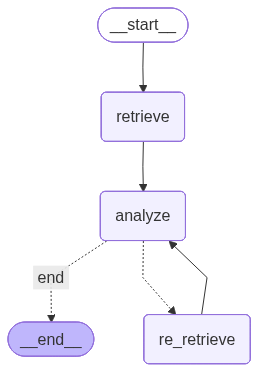

In [28]:
from IPython.display import Image, display

try:
    display(Image(lawgic_agent.get_graph().draw_mermaid_png()))
except Exception:
    print(lawgic_agent.get_graph().draw_mermaid())

todo: still add query definitions?

## Test the Agent

In [29]:
# Prepare a test contract
TEST_CONTRACT = "LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT"

test_pdf_path = pdf_path_lookup[TEST_CONTRACT]
test_docs = PyPDFLoader(test_pdf_path).load()
test_chunks = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, add_start_index=True
).split_documents(test_docs)
test_source = test_docs[0].metadata.get('source', test_pdf_path)

print(f"Test contract: {TEST_CONTRACT}")
print(f"Chunks: {len(test_chunks)}")
print(f"Source: {test_source}")

Test contract: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
Chunks: 71
Source: ../datasets/CUAD_v1/full_contract_pdf/Part_III/Distributor/LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT.PDF


In [30]:
def run_agent(question: str, chunks: list, source: str, verbose: bool = True) -> dict:
    """Run the Lawgic agent on a single question.

    Token budget: ~4,565 tokens (no requery) / ~11,705 tokens (with requery).
    Groq free tier (llama-3.3-70b): ~21 questions/day at 100K TPD.
    Uses invoke() only — no double API calls from stream+invoke.
    """
    initial_state = {
        "question": question,
        "contract_chunks": chunks,
        "source_filter": source,
        "retrieved_docs": [],
        "analysis": "",
        "answer": "",
        "needs_requery": False,
        "requery_term": "",
        "iteration": 0,
    }

    # Single invoke — one set of API calls
    result = lawgic_agent.invoke(initial_state)

    if verbose:
        print(f"Question: {question[:100]}...")
        print(f"Iterations: {result.get('iteration', '?')}")
        print(f"Chunks in context: {len(result.get('retrieved_docs', []))}")
        if result.get('requery_term'):
            print(f"Re-queried with: \"{result['requery_term']}\"")
        print(f"\n--- LLM Analysis ---")
        print(result.get("analysis", "(no analysis)"))
        print(f"\n--- Extracted Answer ---")
        print(result.get("answer", "(no answer)")[:500])

    return result


# Test: A category that FAILED with k=4 in langchain_test (Exclusivity — 0.51 hit rate)
result = run_agent(
    'Highlight the parts (if any) of this contract related to "Exclusivity" '
    'that should be reviewed by a lawyer. Details: Whether there is an exclusive '
    'dealing commitment with the counterparty.',
    test_chunks,
    test_source,
)

Question: Highlight the parts (if any) of this contract related to "Exclusivity" that should be reviewed by a ...
Iterations: 1
Chunks in context: 15

--- LLM Analysis ---
FOUND: The contract excerpts contain provisions related to "Exclusivity" that should be reviewed by a lawyer. Specifically, the following sections are relevant:

* Section 1.1, which states that the "Company hereby appoints Distributor as Company's exclusive distributor within the Market and grants to Distributor the exclusive right to sell and distribute Products within the Market..." (Excerpt 8/15)
* Section 7.1, which states that "Distributor shall have the option of becoming Company's exclusive distributor of such other Products or devices within the Market" (Excerpt 3/15)
* Section D, which states that "The Company appoints the Distributor as an exclusive distributor of Products in the Market, subject to the terms and conditions of this Agreement" (Excerpt 8/15)
* Section 1.6, which states that "In order to main

In [31]:
# Test on hard categories that had low hit rates with the reranker
hard_questions = [
    {
        "question": 'Highlight the parts (if any) of this contract related to "Rofr/Rofo/Rofn" '
                    'that should be reviewed by a lawyer. Details: Whether the contract provides '
                    'the parties with a right of first refusal, right of first offer, or right '
                    'of first negotiation.',
        "category": "ROFR (0.32 with reranker)",
    },
    {
        "question": 'Highlight the parts (if any) of this contract related to "Minimum Commitment" '
                    'that should be reviewed by a lawyer. Details: Whether there is a minimum order '
                    'or purchase commitment.',
        "category": "Minimum Commitment (0.27 with reranker)",
    },
    {
        "question": 'Highlight the parts (if any) of this contract related to "Governing Law" '
                    'that should be reviewed by a lawyer. Details: Which state/country\'s law '
                    'governs the interpretation of the contract.',
        "category": "Governing Law (0.95 baseline)",
    },
]

for i, q in enumerate(hard_questions):
    print(f"\n{'='*70}")
    print(f"  TEST {i+1}: {q['category']}")
    print(f"{'='*70}\n")
    result = run_agent(q['question'], test_chunks, test_source)
    print()


  TEST 1: ROFR (0.32 with reranker)

Question: Highlight the parts (if any) of this contract related to "Rofr/Rofo/Rofn" that should be reviewed by...
Iterations: 1
Chunks in context: 15

--- LLM Analysis ---
FOUND: The contract provides the parties with a "Right of Option" which is similar to a right of first refusal, as stated in Section 7.1: "Should Company introduce other products or devices as contemplated by recital paragraph 'A', Distributor shall have the option of becoming Company's exclusive distributor of such other Products or devices within the Market." 

Additionally, Section 7.2 outlines the "Exercise of Option" which states: "Distributor shall exercise its option to become exclusive Distributor of other Products or devices by serving written notification on Company of its election to become exclusive distributor within thirty (30) days upon..." 

These sections suggest that the Distributor has a right of first refusal to become the exclusive distributor of any new prod

# 5. Table-Aware Retrieval Strategy

**Problem:** Many retrieval failures (e.g., "Minimum Commitment" at 0.27 hit rate)
occur because relevant data appears in tables. Standard PDF-to-text conversion
flattens table structures, destroying the layout that makes them semantically meaningful.

**Strategy: `pymupdf4llm` Markdown Extraction**
- Extracts PDF content as Markdown, preserving table structure
- Tables become readable Markdown tables that the LLM can interpret
- Can be used as an additional agent tool for targeted re-extraction

**Future Enhancement:** Add a `extract_page_tables` tool to the agent graph that:
1. The LLM requests when it suspects tabular data
2. Re-extracts the relevant page(s) using `pymupdf4llm`
3. Feeds the Markdown table back to the LLM for analysis

In [ ]:
import pymupdf4llm


def extract_contract_as_markdown(pdf_path: str, pages: list = None) -> str:
    """Extract contract content as Markdown, preserving tables and structure.

    Args:
        pdf_path: Path to the PDF file
        pages: Optional list of page numbers (0-indexed) to extract.
               If None, extracts all pages.

    Returns:
        Markdown string with preserved table formatting
    """
    md = pymupdf4llm.to_markdown(pdf_path, pages=pages)
    return md


# Demo: extract the test contract
test_md = extract_contract_as_markdown(test_pdf_path, pages=[0, 1])
print(f"Extracted {len(test_md)} chars of Markdown from pages 0-1:")
print()
print(test_md[:2000])

# 6. Full Dataset Benchmark

Run the retrieval benchmark with `k=15` across all 510 contracts.
This measures raw retrieval quality **without LLM calls** (fast).

**Expected outcome:** Higher hit rate than `k=4` (0.81 baseline) since we're
casting a wider net. The agent layer (Section 4) then provides the reasoning
to extract the right answer from that wider context.

In [ ]:
# Uncomment to run the full benchmark (~30-60 min):
# full_results = evaluate_full_dataset(
#     CUAD_PATH, cuad_data, cuad_v1_vector_store, pdf_path_lookup, k=15
# )

# Visualize results:
# plot_results(full_results['aggregate_results'])

# 7. Next Steps

### Phase 2: Enhanced Agent Tools
1. **Table Extraction Tool** — Integrate `extract_contract_as_markdown()` as a
   LangGraph tool node, triggered when the LLM detects table-dependent questions
2. **Section Following** — When the LLM encounters cross-references ("See Annex A"),
   automatically resolve and fetch the referenced section
3. **Multi-hop Reasoning** — Chain multiple retrieval+analysis steps for complex
   questions that span multiple contract sections

### Phase 3: Evaluation
1. **End-to-End Benchmark** — Measure agent answer quality (not just retrieval)
   using exact match and F1 against CUAD ground truth
2. **Per-Category Analysis** — Compare agent performance vs baseline on the
   41 CUAD clause categories, especially the hard ones (Volume Restriction,
   Minimum Commitment, ROFR)
3. **Cost/Latency Profiling** — Measure Groq API calls per question and total latency

### Phase 4: Production
1. **Streaming Responses** — Use LangGraph streaming for real-time agent output
2. **Human-in-the-Loop** — Add checkpoints where a lawyer can review/correct
3. **Caching** — Cache retrieval results and LLM responses for repeated queries